# Kernels

> As in, (positive semidefinite) measures of similarity between points

This section will go over of helper functions used by the `affinis.associations` module, but may be of interest in their own right. 

Much of the difficulty of "straightening out" what a given square matrix represents comes from lack of clarity over the differences between them, and how they relate to one-another. 

- Graph (e.g. adjacency, Laplacian, etc.),
- Kernel (e.g. heat, forest accessibility, page-rank, etc.),
- Distance (shortest-path lengths, generalized euclidean, etc.)



```mermaid
flowchart LR
    Graph <--> Kernel
    Kernel <--> Distance
    
```

This page covers a number of traditional ways to travel between these representations. 

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
plt.rc('figure', figsize=(4.0, 3.0))
imgpath=Path('../../docs/user-guide/img/')

## Graph → Kernel (`proximity`)

In [2]:
import networkx as nx
L = nx.laplacian_matrix(nx.dorogovtsev_goltsev_mendes_graph(3)).toarray()
A = np.diag(np.diag(L))-L

Future versions of `affinis` may include more expansive [coverage](https://doi.org/10.1016/j.ejc.2018.02.002) of kernels on graph vertices. 
For now, we mostly provide an interface to the **forest accessibilities** kernel, which is also a _proximity_ (i.e. satisfies the proximity inequality).


This so-called forest kernel is a parameterized form of an inverse regularized Laplacian: 

$$ Q_{\beta} = \left( I+\beta L \right)^{-1} $$


Entries in this proximity matrix turn out to be the probability that a node ends up sharing a tree with another node, in a randomly sampled spanning forest of the graph (hence the name). 
Since $I+\beta L$ is positive definite (non-singular), the inversion is guaranteed to exist, and will be provably _doubly stochastic_. 


!!! tip "To Read"
    See [Chebotarev & Shamis (2002)](https://doi.org/10.1016/S1571-0653(04)00058-7) and [Avrachenkov et al (2017)](https://doi.org/10.1080/10556788.2016.1193176) for more details on the beautiful _Matrix Forest Theorem_, which plays a key role in the inference performed by [Forest Pursuit][affinis.associations.forest_pursuit]

Our implementation is slightly more efficient than basic `np.linalg.inverse`, since we use the `dpotrf` and `dpotri` for cholesky inversion with cached indexing for PosDef matrices.

Finally, we might want a _logarithmic similarity_, which has useful properties described in the kernels reference above. 
It is not a proximity by itself, but instead the exponentiation of one. 
This can be acheived through diagonal normalization, much like correlation or cosine similarity measures use. 

See [forest][affinis.proximity.forest], [forest_correlation][affinis.proximity.forest_correlation].

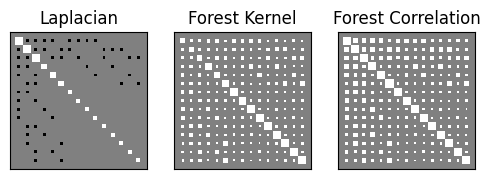

In [5]:
from affinis.proximity import forest, forest_correlation, bilinear_kern
from affinis.plots import hinton

f,ax = plt.subplots(ncols=3, figsize=(6,3))

hinton(L, ax=ax[0])
hinton(forest(L, beta=1.),ax=ax[1])
hinton(forest_correlation(L, beta=1.), ax=ax[2])

ax[0].set_title('Laplacian')
ax[1].set_title('Forest Kernel')
ax[2].set_title('Forest Correlation')

plt.savefig(imgpath/'laplacian.webp')

![laplacian matrix](img/laplacian.webp)

Another useful tool in this module is the `sinkhorn` function, which performs iterated proportional fitting (i.e. the Sinkhorn-Knopp iterations) to project a sqare matrix to it's nearest _doubly stochastic_ counterpart. 

This might e.g. be a useful way to approximate the forest kernel, given some other similarity on the graph. 
It's also the basis for [doubly_stochastic_filter][affinis.associations.doubly_stochastic_filter].

In [6]:
from scipy.sparse.csgraph import shortest_path
from affinis.proximity import sinkhorn 

print(sinkhorn(np.exp(-shortest_path(A))).sum(axis=0))
"""[OUT]:
[1.0000004  1.0000004  1.0000004  1.00000007 1.00000007 1.00000007
 1.00000089 1.00000089 1.         1.         1.00000089 1.
 1.         1.         1.        ]

""";

[1.0000004  1.0000004  1.0000004  1.00000007 1.00000007 1.00000007
 1.00000089 1.00000089 1.         1.         1.00000089 1.
 1.         1.         1.        ]


## Kernel → Graph (`filter`)



It's commonly necessary to select a threshold value over which an edge "exists" and below which it doesn't. Affinis implements this simple thresholding as [threshold_value][affinis.filter.threshold_value]


Since edge recovery is very often an _unsupervised_ problem, a common way to select a relatively sparse threshold value is by removing edges until just before the graph would become disconnected. 

`affinis` has implemented a fast routine for removing edges until the graph is about to become disconnected (using a binary search and breadth-first connectivity checks). 

See [threshold_connected][affinis.filter.threshold_connected]


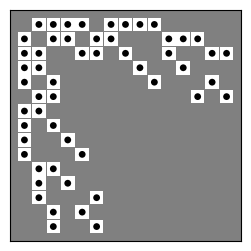

In [17]:
from affinis.filter import threshold_connected

hinton(A)
hinton(-threshold_connected(forest_correlation(L)), marker='.')
plt.savefig(imgpath/'filter-recovery.webp')

![conectivity filter](img/filter-recovery.webp)

## Kernel → Distance (`distance`)

From a given kernels, by we are able to turn them into (Euclidian) distance metrics, using the bilinear form. 
See [docs][affinis.distance.bilinear_dists].

For forest kernels, this has been shortened to quickly retrive the **linear** and **logarithmic** forms of the bilinear distance metric on a graph using [adjusted_forest_dists][affinis.distance.adjusted_forest_dists] and [generalized_graph_dists][affinis.distance.generalized_graph_dists], respectively. 

Interestingly, in the limit of $\beta\rightarrow\infty$, the [adjusted_forest_dists][affinis.distance.adjusted_forest_dists] will tend toward the Commute-time kernel (i.e. effective resistances). 
The same is true for the [generalized_graph_dists][affinis.distance.generalized_graph_dists], though in this normalized case, the lower limit $\beta\rightarrow 0^+$ will also converge to a scalar multiple of the shortest path distances. 
In this way, the forest distances can be thought of as a smooth interpolation from the shortest paths to the effective resistances. 

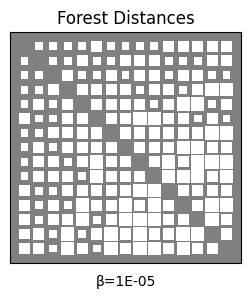

In [30]:
from affinis.distance import adjusted_forest_dists, generalized_graph_dists
import matplotlib.animation as animation

fig, ax = plt.subplots()
scat = hinton(generalized_graph_dists(L, beta=1e-5), ax=ax)
plt.title('Forest Distances')
annot = ax.annotate('β=',(0.5,-.1), xycoords='axes fraction', ha='center')

betas = np.logspace(-5,5)
betas = np.hstack((
    np.ones_like(betas)*1e-5,
    betas,
    np.ones_like(betas)*1e5,
    betas[::-1]
))

def update(frame):
    beta = betas[frame]
    D = generalized_graph_dists(L, beta=beta)
    newscat = hinton(D, update_from=scat)
    annot.set_text(f'β={beta:.0E}')
    return (newscat ,annot)

ani = animation.FuncAnimation(fig=fig, func=update, frames=betas.shape[0], interval=30)
ani.save(filename=imgpath/"forest-dists.webp", writer="pillow")

# hinton(bilinear_dists(forest(L)))

![](img/forest-dists.webp)